# Домашнее задание 4
Анализ и заполнение пропусков в датасете

## Загрузка данных
Считываем датасет из файла `loan_prediction_dataset.csv`

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid')
df = pd.read_csv('loan_prediction_dataset.csv')
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Основная информация
Смотрим структуру и статистики датасета

In [2]:
print(f'Размер датасета: {df.shape[0]} строк и {df.shape[1]} столбцов')
print()
df.info()
print()
display(df.describe())
display(df.describe(include='object'))


Размер датасета: 614 строк и 13 столбцов

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB



,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


## Таблица пропусков
Считаем абсолютное число и процент пропусков по каждому столбцу

In [3]:
missing_table = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().sum() / len(df) * 100).round(2)
})
missing_table


,missing_count,missing_percent
Loan_ID,0,0.00
Gender,13,2.12
Married,3,0.49
Dependents,15,2.44
Education,0,0.00
Self_Employed,32,5.21
ApplicantIncome,0,0.00
CoapplicantIncome,0,0.00
LoanAmount,22,3.58
Loan_Amount_Term,14,2.28


## Визуализация пропусков
Строим матрицу пропусков и тепловую карту пропусков

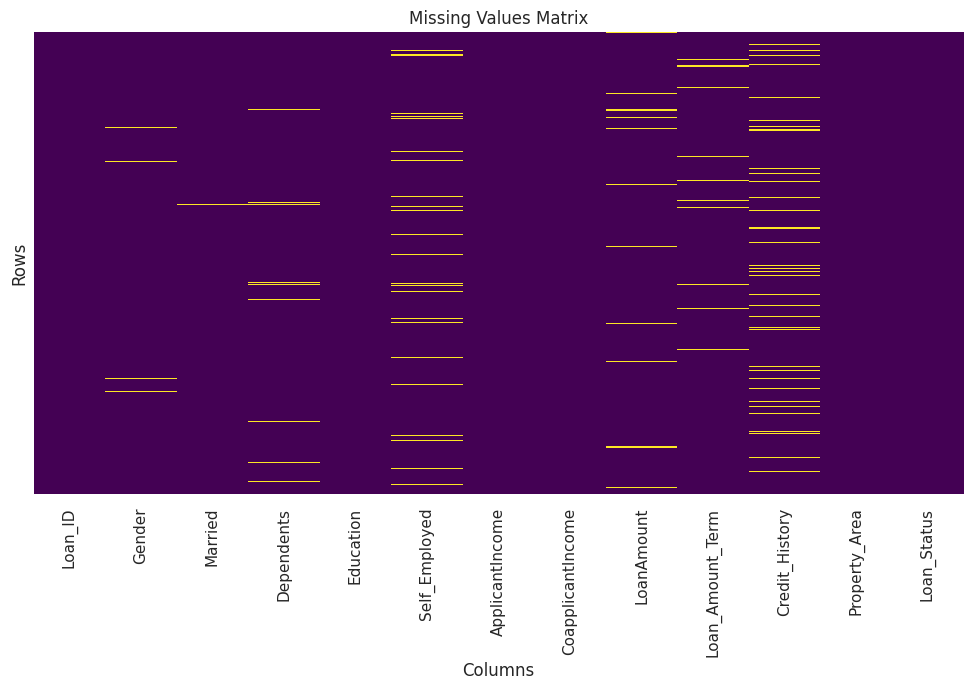

In [4]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Matrix')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()


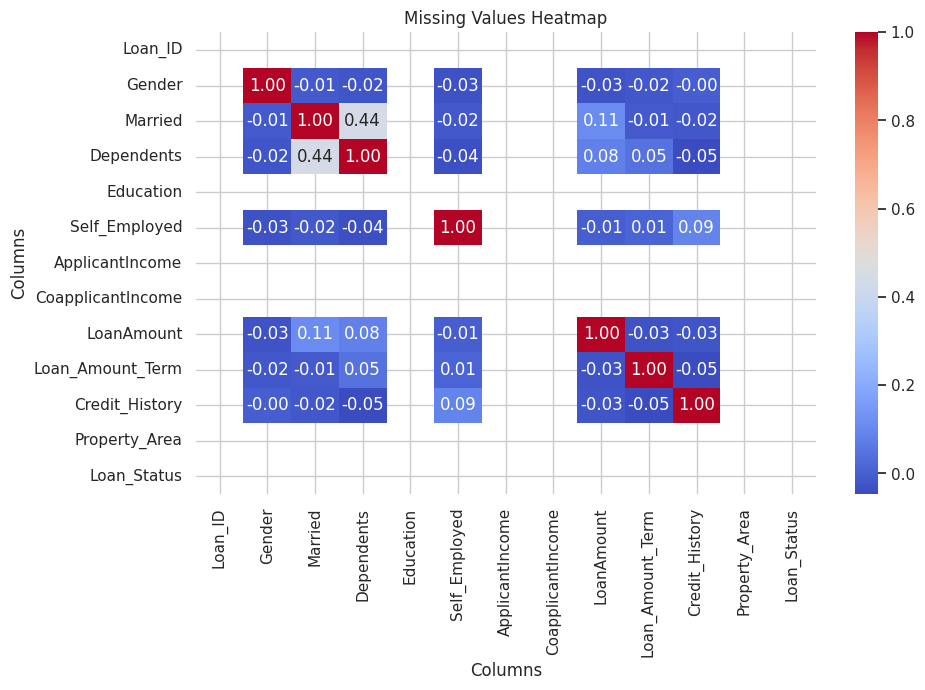

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna().corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.ylabel('Columns')
plt.show()


## Интерпретация графиков
Пропуски есть только в части столбцов и они распределены неравномерно. Наиболее заметны пропуски в `Credit_History`, `Self_Employed` и `LoanAmount`, а тепловая карта помогает увидеть, где пропуски могут встречаться совместно

## Числовые и категориальные признаки с пропусками
Разделяем столбцы с пропусками по типам

In [6]:
columns_with_missing = df.columns[df.isna().any()].tolist()
numeric_missing = df[columns_with_missing].select_dtypes(include='number').columns.tolist()
categorical_missing = df[columns_with_missing].select_dtypes(exclude='number').columns.tolist()

print('Числовые признаки с пропусками:', numeric_missing)
print('Категориальные признаки с пропусками:', categorical_missing)


Числовые признаки с пропусками: ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Категориальные признаки с пропусками: ['Gender', 'Married', 'Dependents', 'Self_Employed']


## Статистики до заполнения
Сохраняем статистики до обработки пропусков

In [7]:
before_numeric = df[numeric_missing].describe()
before_categorical = df[categorical_missing].describe()

display(before_numeric)
display(before_categorical)


,LoanAmount,Loan_Amount_Term,Credit_History
count,592.000000,600.00000,564.000000
mean,146.412162,342.00000,0.842199
std,85.587325,65.12041,0.364878
min,9.000000,12.00000,0.000000
25%,100.000000,360.00000,1.000000
50%,128.000000,360.00000,1.000000
75%,168.000000,360.00000,1.000000
max,700.000000,480.00000,1.000000


,Gender,Married,Dependents,Self_Employed
count,601,611,599,582
unique,2,2,4,2
top,Male,Yes,0,No
freq,489,398,345,500


## Заполнение пропусков
Для числовых признаков используем медиану, для категориальных — моду

In [8]:
df_filled = df.copy()

for column in numeric_missing:
    df_filled[column] = df_filled[column].fillna(df_filled[column].median())

for column in categorical_missing:
    df_filled[column] = df_filled[column].fillna(df_filled[column].mode()[0])

df_filled.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Почему выбран такой способ
Медиана устойчива к выбросам в числовых данных, а мода подходит для заполнения наиболее частым значением в категориальных признаках

## Проверка заполнения
Проверяем, что пропусков больше нет

In [9]:
missing_after = pd.DataFrame({
    'missing_count': df_filled.isna().sum(),
    'missing_percent': (df_filled.isna().sum() / len(df_filled) * 100).round(2)
})

display(missing_after)
print('Общее число пропусков после заполнения:', int(df_filled.isna().sum().sum()))


,missing_count,missing_percent
Loan_ID,0,0.0
Gender,0,0.0
Married,0,0.0
Dependents,0,0.0
Education,0,0.0
Self_Employed,0,0.0
ApplicantIncome,0,0.0
CoapplicantIncome,0,0.0
LoanAmount,0,0.0
Loan_Amount_Term,0,0.0


Общее число пропусков после заполнения: 0


## Статистики после заполнения
Сравниваем данные после обработки пропусков

In [10]:
after_numeric = df_filled[numeric_missing].describe()
after_categorical = df_filled[categorical_missing].describe()

display(after_numeric)
display(after_categorical)


,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000
mean,145.752443,342.410423,0.855049
std,84.107233,64.428629,0.352339
min,9.000000,12.000000,0.000000
25%,100.250000,360.000000,1.000000
50%,128.000000,360.000000,1.000000
75%,164.750000,360.000000,1.000000
max,700.000000,480.000000,1.000000


,Gender,Married,Dependents,Self_Employed
count,614,614,614,614
unique,2,2,4,2
top,Male,Yes,0,No
freq,502,401,360,532


## Краткий вывод

После заполнения количество наблюдений в столбцах с пропусками стало полным. Средние и медианы числовых признаков изменились незначительно, а в категориальных признаках увеличилась частота самых популярных значений